# Import Libraries

In [1]:
#torch.cuda.is_available()

# Import Libraries

In [174]:
data_dir = "D:/Shahid Sir/Gastrointestinal Tract Kvasir Dataset"# Datasets path
data_dir = pathlib.Path(data_dir)
data_dir

WindowsPath('D:/Shahid Sir/Gastrointestinal Tract Kvasir Dataset')

In [175]:
path = "D:/Shahid Sir/Gastrointestinal Tract Kvasir Dataset"
dir_list = [os.path.join(path,i) for i in os.listdir(path)]
size_dict = {}
for i,value in enumerate(dir_list):
    size_dict[os.listdir(path)[i]] = len(os.listdir(value))
size_dict 

{'DLP': 500,
 'DRM': 500,
 'EP': 500,
 'NC': 500,
 'NP': 500,
 'NZL': 500,
 'PP': 500,
 'UC': 500}

# Data Extraction

In [176]:
DLP = list(data_dir.glob('DLP/*'))
DRM = list(data_dir.glob('DRM/*'))
EP = list(data_dir.glob('EP/*'))
NC = list(data_dir.glob('NC/*'))
NP = list(data_dir.glob('NP/*'))
NZL = list(data_dir.glob('NZL/*'))
PP = list(data_dir.glob('PP/*'))
UC = list(data_dir.glob('UC/*'))

# Class Labelling

In [177]:
df_images = {
    'DLP' : DLP,
    'DRM' : DRM,
    'EP' : EP,
    'NC' : NC,
    'NP' : NP,
    'NZL' : NZL,
    'PP' : PP,
    'UC' : UC,
}

df_labels = {
    'DLP' : 0,
    'DRM' : 1,
    'EP' : 2,
    'NC' : 3,
    'NP' : 4,
    'NZL' : 5,
    'PP' : 6,
    'UC' : 7,
}

print(df_images['DLP'][0])

D:\Shahid Sir\Gastrointestinal Tract Kvasir Dataset\DLP\0053d7cd-549c-48cd-b370-b4ad64a8098a.jpg


# Visualisation of Classes

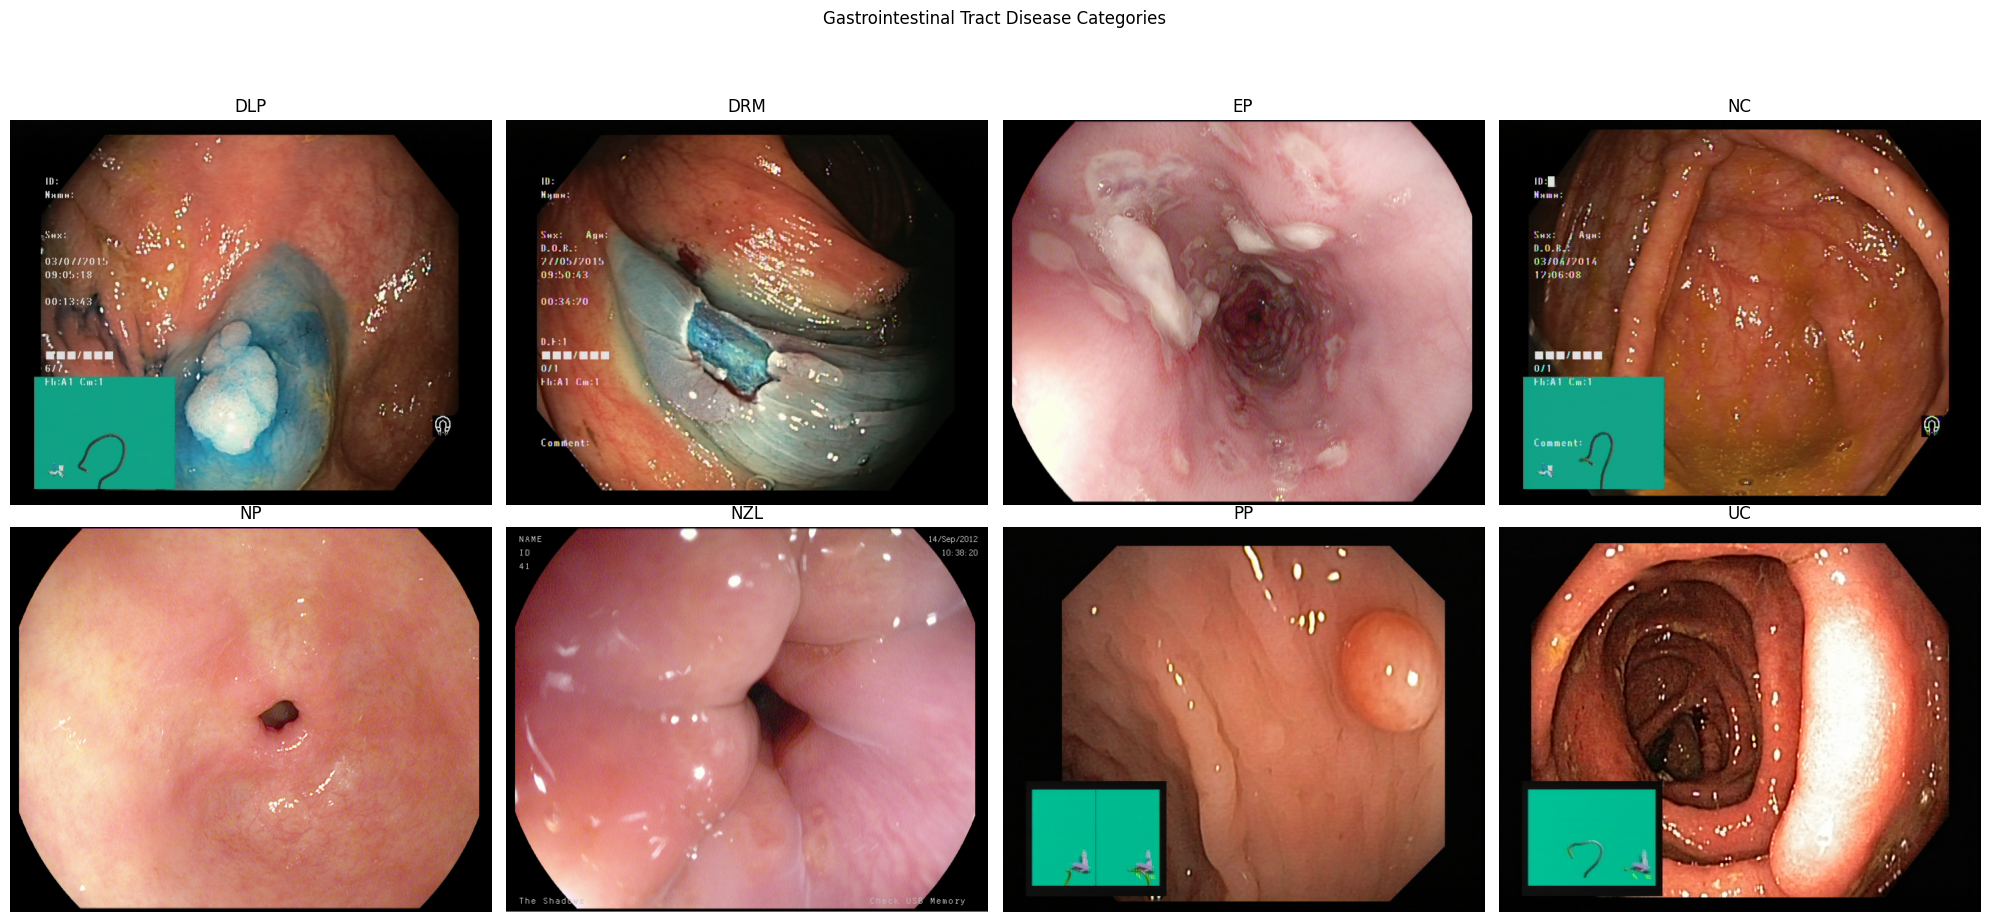

In [178]:
import matplotlib.pyplot as plt
import cv2

# Create a 2x4 grid for subplots
fig, ax = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
fig.suptitle('Gastrointestinal Tract Disease Categories')

# Read images
DLP_image = cv2.imread(str(df_images['DLP'][0]))
DRM_image = cv2.imread(str(df_images['DRM'][0]))
EP_image = cv2.imread(str(df_images['EP'][0]))
NC_image = cv2.imread(str(df_images['NC'][0]))
NP_image = cv2.imread(str(df_images['NP'][0]))
NZL_image = cv2.imread(str(df_images['NZL'][0]))
PP_image = cv2.imread(str(df_images['PP'][0]))
UC_image = cv2.imread(str(df_images['UC'][0]))

# Titles for the subplots
titles = ['DLP', 'DRM', 'EP', 'NC', 'NP', 'NZL', 'PP', 'UC']

# Flatten the axes array for easier indexing
ax_flat = ax.flatten()

# Display images and titles in the subplots
for i in range(8):
    ax_flat[i].set_title(titles[i])
    ax_flat[i].imshow(cv2.cvtColor(eval(f"{titles[i]}_image"), cv2.COLOR_BGR2RGB))  # Convert from BGR to RGB
    ax_flat[i].axis('off')  # Hide axes

plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout to make room for the title
plt.show()


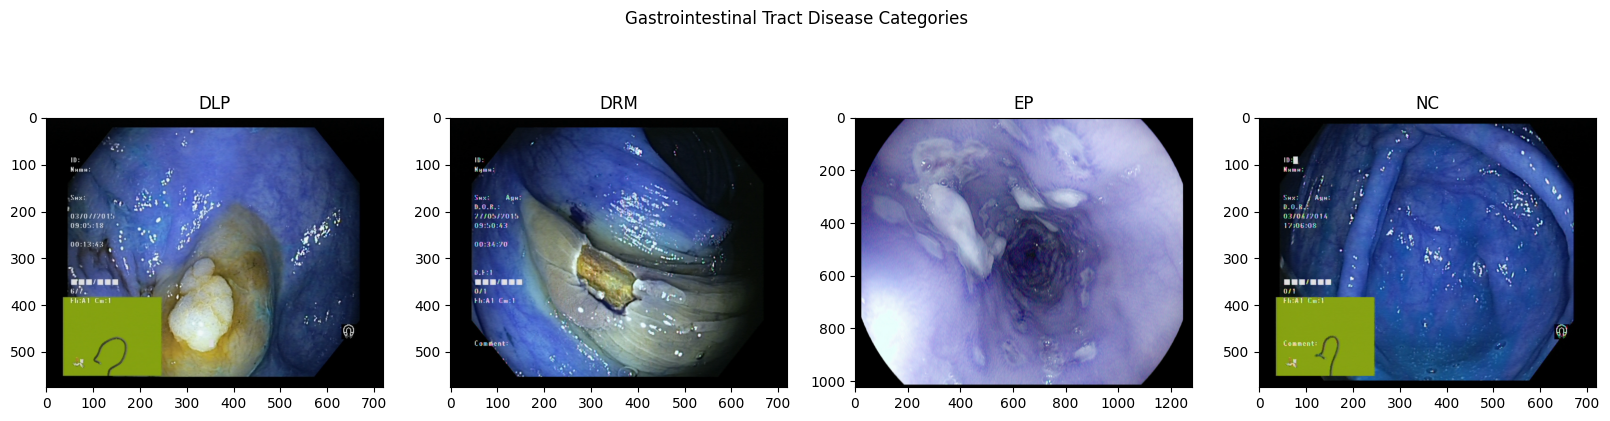

In [179]:
fig, ax = plt.subplots(ncols=4, figsize=(20,5))
fig.suptitle('Gastrointestinal Tract Disease Categories')

img = str(df_images['DLP'][0])
#img.shape

DLP_image = cv2.imread(str(df_images['DLP'][0]))
DRM_image = cv2.imread(str(df_images['DRM'][0]))
EP_image = cv2.imread(str(df_images['EP'][0]))
NC_image = cv2.imread(str(df_images['NC'][0]))

ax[0].set_title('DLP')
ax[1].set_title('DRM')
ax[2].set_title('EP')
ax[3].set_title('NC')

ax[0].imshow(DLP_image)
ax[1].imshow(DRM_image)
ax[2].imshow(EP_image)
ax[3].imshow(NC_image)

plt.show()

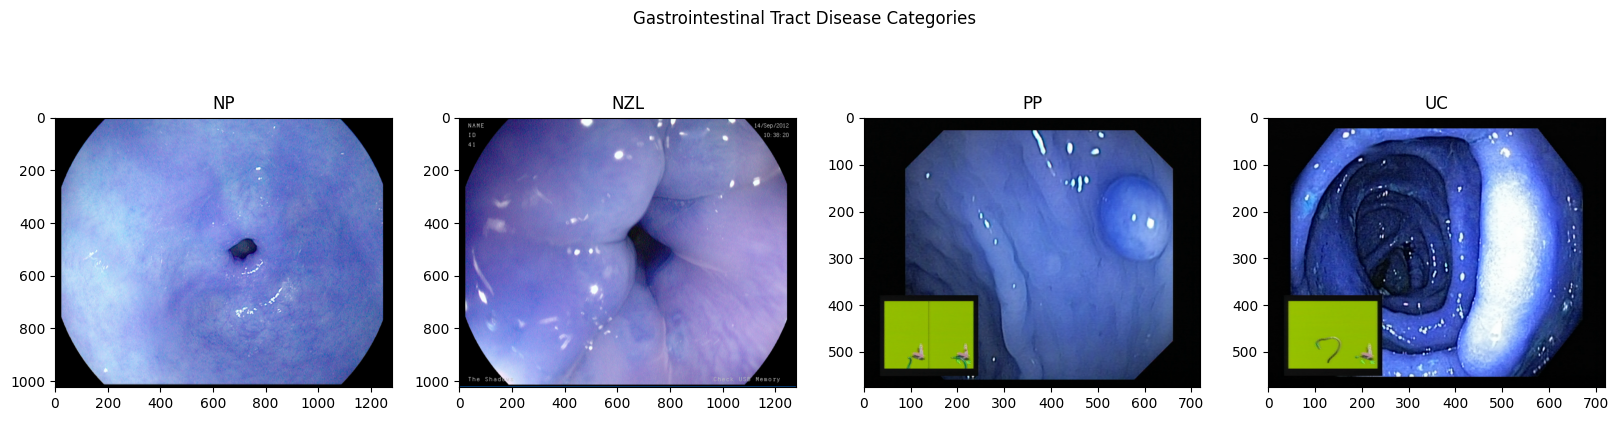

In [180]:
fig, ax = plt.subplots(ncols=4, figsize=(20,5))
fig.suptitle('Gastrointestinal Tract Disease Categories')

img = str(df_images['DLP'][0])
#img.shape

NP_image = cv2.imread(str(df_images['NP'][0]))
NZL_image = cv2.imread(str(df_images['NZL'][0]))
PP_image = cv2.imread(str(df_images['PP'][0]))
UC_image = cv2.imread(str(df_images['UC'][0]))


ax[0].set_title('NP')
ax[1].set_title('NZL')
ax[2].set_title('PP')
ax[3].set_title('UC')

ax[0].imshow(NP_image)
ax[1].imshow(NZL_image)
ax[2].imshow(PP_image)
ax[3].imshow(UC_image)


plt.show()

In [181]:
X, y = [], [] 
for label, images in df_images.items():
    for image in images:
        img = cv2.imread(str(image))
        resized_img = cv2.resize(img, (224, 224)) 
        X.append(resized_img) 
        y.append(df_labels[label])

# Reading Image Dataset in X, Y

In [182]:
X = np.array(X)
X = X/255
y = np.array(y)
print(X.shape)

(4000, 224, 224, 3)


# Splitting of the Dataset

In [183]:
from sklearn.model_selection import train_test_split

X_train, X_test_val, y_train, y_test_val = train_test_split(X, y,test_size=0.30)
X_test, X_val, y_test, y_val = train_test_split(X_test_val, y_test_val,test_size=0.33)
#X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.40)

In [184]:
print(X_train.shape)
print(X_test.shape)
print(X_test_val.shape)
print(X_val.shape)
print(y_train.shape)
print(y_test.shape)
print(y_test_val.shape)
print(y_val.shape)

(2800, 224, 224, 3)
(804, 224, 224, 3)
(1200, 224, 224, 3)
(396, 224, 224, 3)
(2800,)
(804,)
(1200,)
(396,)
